In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patches
from shapely import geometry
from tqdm import tqdm
import random
from scipy.optimize import minimize
import slab_interactions as slab

In [22]:

n = 8
pattern = (0.5, 1)
slab = ((0, 0), (0, 2), (2, 2), (2, 0))
rnd_coef = [0.1, 0.1, 0.1]
min_bound = np.array([0, 0, 0])
max_bound = np.array([2, 2, 2 * np.pi])


In [ ]:
def s_intersection(a, b):
    poly1 = geometry.Polygon(a)
    poly2 = geometry.Polygon(b)
    intersection = poly1.intersection(poly2)
    return intersection.area


def real_cords(x):
    p = x[:2]
    phi = x[2]
    return geometry.Polygon([
        [p[0], p[1]],
        [p[0] + pattern[0] * np.cos(phi), p[1] + pattern[0] * np.sin(phi)],
        [p[0] + pattern[0] * np.cos(phi) - pattern[1] * np.sin(phi),
         p[1] + pattern[0] * np.sin(phi) + pattern[1] * np.cos(phi)],
        [p[0] - pattern[1] * np.sin(phi), p[1] + pattern[1] * np.cos(phi)]
    ])

def real_real_cords(x):
    p = x[:2]
    phi = x[2]
    return [
        [p[0], p[1]],
        [p[0] + pattern[0] * np.cos(phi), p[1] + pattern[0] * np.sin(phi)],
        [p[0] + pattern[0] * np.cos(phi) - pattern[1] * np.sin(phi),
         p[1] + pattern[0] * np.sin(phi) + pattern[1] * np.cos(phi)],
        [p[0] - pattern[1] * np.sin(phi), p[1] + pattern[1] * np.cos(phi)]
    ]


def func(all_pattern2):
    s = 0
    # Суммируем площади пересечений между фигурами
    for i in range(len(all_pattern2)):
        for j in range(i + 1, len(all_pattern2)):
            s += s_intersection(real_cords(all_pattern2[i]), real_cords(all_pattern2[j]))
    # Пени за выход за пределы slab
    for i in all_pattern2:
        s += real_cords(i).area - s_intersection(geometry.Polygon(slab), real_cords(i))
    return s


In [ ]:

def get_neighbors(solution, rnd_coef):
    neighbors = []
    n = len(solution)
    for _ in range(10):
        neighbor = list(solution)
        idx = random.randint(0, n - 1)
        old_coord = neighbor[idx]
        new_coord = (
            max(min_bound[0], min(old_coord[0] + random.uniform(-rnd_coef[0], rnd_coef[0]), max_bound[0])),
            max(min_bound[1], min(old_coord[1] + random.uniform(-rnd_coef[1], rnd_coef[1]), max_bound[1])),
            max(min_bound[2], min(old_coord[2] + random.uniform(-rnd_coef[2], rnd_coef[2]), max_bound[2])),
        )
        neighbor[idx] = new_coord
        neighbors.append(tuple(neighbor))
    return neighbors

def tabu_search(initial_solution, max_iterations, tabu_list_size, rnd_coef):
    current_solution = initial_solution
    best_solution = initial_solution
    tabu_list = []

    for _ in tqdm(range(max_iterations)):
        neighbors = get_neighbors(current_solution, rnd_coef)
        best_neighbor = None
        best_neighbor_fitness = float('inf')

        for neighbor in neighbors:
            if neighbor not in tabu_list:
                fitness = func(neighbor)
                if fitness < best_neighbor_fitness:
                    best_neighbor = neighbor
                    best_neighbor_fitness = fitness

        if best_neighbor is None:
            break

        current_solution = best_neighbor
        tabu_list.append(best_neighbor)
        if len(tabu_list) > tabu_list_size:
            tabu_list.pop(0)

        if func(current_solution) < func(best_solution):
            best_solution = current_solution

    return best_solution

initial_solution = []
for _ in range(n):
    initial_solution.append((
        random.uniform(min_bound[0], max_bound[0]),
        random.uniform(min_bound[1], max_bound[1]),
        random.uniform(min_bound[2], max_bound[2])
    ))
initial_solution = tuple(initial_solution)

max_iterations = 1000
tabu_list_size = 10
best_solution = tabu_search(initial_solution, max_iterations, tabu_list_size, rnd_coef)


In [ ]:

print("Best solution:", best_solution)
print("Best fitness:", func(best_solution))


Best solution: ((np.float64(1.9569188714769594), np.float64(1.5402256591778798), np.float64(3.1558433845627567)), (np.float64(0.9825445287726405), np.float64(0.4953925716915599), np.float64(0.04810048197905723)), (np.float64(0.4953595400710697), np.float64(1.9998793431185125), np.float64(3.105039734596019)), (np.float64(1.0020070769518281), np.int64(0), np.float64(1.5735501447045719)), (np.float64(0.45729812136826253), np.float64(0.9908152509694526), np.float64(6.235530356615597)), (np.float64(0.9696528840853827), np.float64(0.5050893128786413), np.float64(1.5494412413866647)), (np.float64(1.9848359293203195), np.float64(1.566915213191758), np.float64(1.6221580626660603)), (np.float64(1.0058249489691335), np.float64(0.5024506593404037), np.float64(4.739611818498121)))
Best fitness: 0.13573958122360555


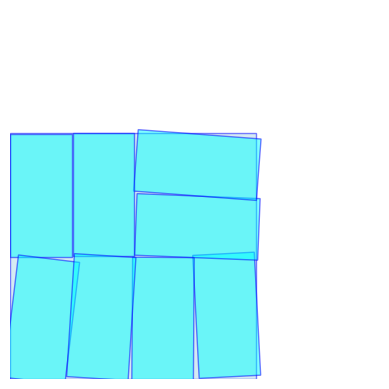

In [30]:

fig, ax = plt.subplots()
polygon = patches.Polygon(slab, closed=True, fill=True, edgecolor='blue', facecolor='lightblue', alpha=0.5)
ax.add_patch(polygon)

for pos in best_solution:
    rect = patches.Polygon(np.array(real_real_cords(pos)), closed=True, fill=True, edgecolor='blue', facecolor='cyan', alpha=0.5)
    ax.add_patch(rect)



ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')
ax.grid(True)
ax.set_axis_off()
plt.show()


In [31]:
def objective(x):
    patterns = [x[i:i+3] for i in range(0, len(x), 3)]
    return func(patterns)

x0 = np.array([coord for pattern in best_solution for coord in pattern])

bounds = [(min_bound[i % 3], max_bound[i % 3]) for i in range(len(x0))]
result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds, options={'maxiter': 100})

improved_solution = [tuple(result.x[i:i+3]) for i in range(0, len(result.x), 3)]
improved_solution = tuple(improved_solution)

print("Improved solution:", improved_solution)
print("Improved fitness:", func(improved_solution))


Improved solution: ((np.float64(2.2684094041104603e-06), np.float64(0.999995954485062), np.float64(4.316762500698437e-06)), (np.float64(1.999952567557981), np.float64(1.0000473152453597), np.float64(3.1416831468775666)), (np.float64(1.4999570745922846), np.float64(1.0000106916567069), np.float64(3.14167041599698)), (np.float64(0.49998739720503227), np.float64(1.000000107962814), np.float64(3.141613427168193)), (np.float64(0.9999891266430011), np.float64(1.4999650560128825), np.float64(4.712470004261596)), (np.float64(2.0), np.float64(1.500031592366504), np.float64(1.5708528692136072)), (np.float64(0.49999517970891233), np.float64(1.0000011227530117), np.float64(6.283178463211695)), (np.float64(0.999961861745768), np.float64(1.0000168524376005), np.float64(3.141656569094708)))
Improved fitness: 6.75617748795746e-05


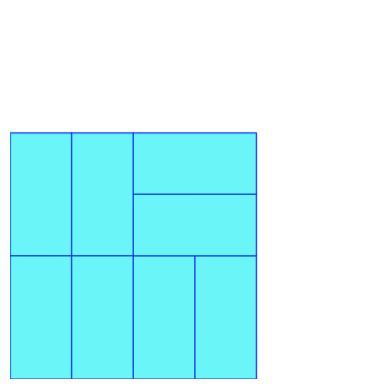

Относителоьное улучшение: 0.9994214992098299


In [32]:

# Визуализация улучшенного решения
fig, ax = plt.subplots()
polygon = patches.Polygon(slab, closed=True, fill=True, edgecolor='blue', facecolor='lightblue', alpha=0.5)
ax.add_patch(polygon)

for pos in improved_solution:
    rect = patches.Polygon(real_real_cords(pos), closed=True, fill=True, edgecolor='blue', facecolor='cyan', alpha=0.5)
    ax.add_patch(rect)

ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')
ax.grid(True)
ax.set_axis_off()
plt.show()

print("Относителоьное улучшение:", (func(best_solution) - func(improved_solution))/func(best_solution))